Step 1: Landscape engineering (preprocess)

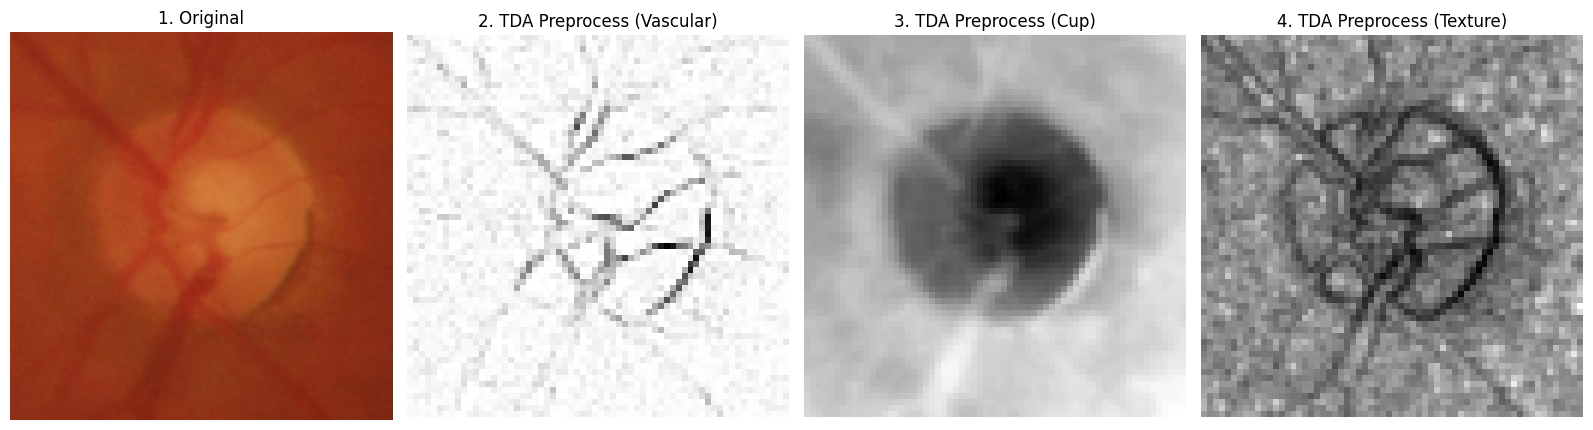

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import frangi
from skimage.filters.rank import entropy
from skimage.morphology import disk


def preprocess_for_tda_vascular_test(img_bgr):
    """Produce normalized vessel image (Green channel)"""
    # Split RGB Channels
    _, green, _ = cv2.split(img_bgr)
    
    # blur slightly to remove noise, then run Frangi
    g_blur = cv2.GaussianBlur(green, (5, 5), 0)
    frangi_map = frangi(g_blur, sigmas=range(2, 6, 1), black_ridges=True)
    
    # normalize output to 0.0 - 1.0
    vascular_landscape = cv2.normalize(frangi_map, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)

    # resize
    small_vascular = cv2.resize(vascular_landscape, (64, 64), interpolation=cv2.INTER_AREA)
    
    # invert
    vascular_norm = 1.0 - (small_vascular / 255.0)
    
    return vascular_norm

def preprocess_for_tda_cup_test(img_bgr):
    """Produce normalized cup image (Red channel)"""
    # Split RGB Channels
    _, _, red = cv2.split(img_bgr)
    
    # blur heavily to remove vessel shadows, leaving the geometry of optic disc
    r_blur = cv2.GaussianBlur(red, (21, 21), 0)
    
    # normalize output to 0.0 - 1.0
    cup_landscape = cv2.normalize(r_blur, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)

    # resize
    small_cup = cv2.resize(cup_landscape, (64, 64), interpolation=cv2.INTER_AREA)
    
    # invert
    cup_norm =  1.0 - (small_cup / 255.0)
    
    return cup_norm

def preprocess_for_tda_texture_test(img_bgr):
    """Produce normalized texture image (Grayscale)"""
    # Convert to grayscale
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    
    # Calculate Local Entropy (Texture)
    # A disk of 5 pixels sweeps the image. 
    # Smooth areas get a low score (0). Rough/patchy areas get a high score.
    texture_map = entropy(gray, disk(5))
    
    # normalize output to 0.0 - 1.0
    texture_landscape = cv2.normalize(texture_map, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    
    # resize
    small_texture = cv2.resize(texture_landscape, (64, 64), interpolation=cv2.INTER_AREA)
    
    # invert
    texture_norm = 1.0 - (small_texture/ 255.0)
    
    return texture_norm

TEST_IMAGE_PATH = "ROI/positive/86_0.jpg"
img_raw = cv2.imread(TEST_IMAGE_PATH)
img_rgb_original = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

# Run the three pipelines
tda_preprocessed_vascular = preprocess_for_tda_vascular_test(img_raw)
tda_preprocessed_cup = preprocess_for_tda_cup_test(img_raw)
tda_preprocessed_texture = preprocess_for_tda_texture_test(img_raw)

# Visualize
plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.imshow(img_rgb_original)
plt.title("1. Original")
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(tda_preprocessed_vascular, cmap='gray')
plt.title("2. TDA Preprocess (Vascular)")
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(tda_preprocessed_cup, cmap='gray')
plt.title("3. TDA Preprocess (Cup)")
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(tda_preprocessed_texture, cmap='gray')
plt.title("4. TDA Preprocess (Texture)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import cv2
import numpy as np
from skimage.filters import frangi
from skimage.filters.rank import entropy
from skimage.morphology import disk


def preprocess_for_tda_vascular(img_bgr):
    """Produce normalized vessel image (Green channel)"""
    _, green, _ = cv2.split(img_bgr)

    g_blur = cv2.GaussianBlur(green, (5, 5), 0)
    frangi_map = frangi(g_blur, sigmas=range(2, 6), black_ridges=True)

    vascular_landscape = cv2.normalize(
        frangi_map, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F
    )

    small_vascular = cv2.resize(vascular_landscape, (64, 64), interpolation=cv2.INTER_AREA)
    vascular_norm = 1.0 - small_vascular

    return (vascular_norm * 255).astype(np.uint8)


def preprocess_for_tda_cup(img_bgr):
    """Produce normalized cup image (Red channel)"""
    _, _, red = cv2.split(img_bgr)

    r_blur = cv2.GaussianBlur(red, (21, 21), 0)

    cup_landscape = cv2.normalize(
        r_blur, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F
    )

    small_cup = cv2.resize(cup_landscape, (64, 64), interpolation=cv2.INTER_AREA)
    cup_norm = 1.0 - small_cup

    return (cup_norm * 255).astype(np.uint8)


def preprocess_for_tda_texture(img_bgr):
    """Produce normalized texture image (Grayscale)"""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    texture_map = entropy(gray, disk(5))

    texture_landscape = cv2.normalize(
        texture_map, None, 0, 1.0, cv2.NORM_MINMAX, dtype=cv2.CV_32F
    )

    small_texture = cv2.resize(texture_landscape, (64, 64), interpolation=cv2.INTER_AREA)
    texture_norm = 1.0 - small_texture

    return (texture_norm * 255).astype(np.uint8)


# =========================
# 1. INPUT / OUTPUT ROOT
# =========================
INPUT_ROOT = Path("ROI")
OUTPUT_ROOT = Path("ROI_TDA")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

CLASS_MAP = {
    "negative": 0,
    "positive": 1
}

records = []

# =========================
# 2. LOOP THROUGH CLASSES
# =========================
for class_name, label in CLASS_MAP.items():
    input_dir = INPUT_ROOT / class_name
    output_dir = OUTPUT_ROOT / class_name
    output_dir.mkdir(parents=True, exist_ok=True)

    image_files = list(input_dir.glob("*.jpg"))

    print(f"Found {len(image_files)} images in {input_dir}")
    print(f"Processing and saving to {output_dir}...")

    for img_path in tqdm(image_files, desc=f"Processing {class_name}"):
        img = cv2.imread(str(img_path))

        if img is None:
            print(f"Warning: cannot read image: {img_path}")
            continue

        vessel_img = preprocess_for_tda_vascular(img)
        cup_img = preprocess_for_tda_cup(img)
        texture_img = preprocess_for_tda_texture(img)

        base_name = img_path.stem

        vessel_path = output_dir / f"{base_name}_vessel.png"
        cup_path = output_dir / f"{base_name}_cup.png"
        texture_path = output_dir / f"{base_name}_texture.png"

        cv2.imwrite(str(vessel_path), vessel_img)
        cv2.imwrite(str(cup_path), cup_img)
        cv2.imwrite(str(texture_path), texture_img)

        # 假设文件名格式像 82_0.jpg，则 patient_id = 82
        patient_id = base_name.split("_")[0]

        records.append({
            "image_name": img_path.name,
            "base_name": base_name,
            "patient_id": patient_id,
            "label": label,
            "class_name": class_name,
            "original_path": str(img_path),
            "vessel_path": str(vessel_path),
            "cup_path": str(cup_path),
            "texture_path": str(texture_path),
        })

# =========================
# 3. SAVE MASTER CSV
# =========================
tda_master = pd.DataFrame(records)
tda_master.to_csv("tda_master.csv", index=False)

print("✅ Done! All ROI images are processed.")
print("✅ tda_master.csv saved.")
print(tda_master.head())

Found 199 images in ROI\negative
Processing and saving to ROI_TDA\negative...


Processing negative: 100%|██████████| 199/199 [02:16<00:00,  1.46it/s]


Found 548 images in ROI\positive
Processing and saving to ROI_TDA\positive...


Processing positive: 100%|██████████| 548/548 [07:11<00:00,  1.27it/s]

✅ Done! All ROI images are processed.
✅ tda_master.csv saved.
  image_name base_name patient_id  label class_name           original_path  \
0  187_0.jpg     187_0        187      0   negative  ROI\negative\187_0.jpg   
1  188_0.jpg     188_0        188      0   negative  ROI\negative\188_0.jpg   
2  188_1.jpg     188_1        188      0   negative  ROI\negative\188_1.jpg   
3  189_0.jpg     189_0        189      0   negative  ROI\negative\189_0.jpg   
4  189_1.jpg     189_1        189      0   negative  ROI\negative\189_1.jpg   

                         vessel_path                        cup_path  \
0  ROI_TDA\negative\187_0_vessel.png  ROI_TDA\negative\187_0_cup.png   
1  ROI_TDA\negative\188_0_vessel.png  ROI_TDA\negative\188_0_cup.png   
2  ROI_TDA\negative\188_1_vessel.png  ROI_TDA\negative\188_1_cup.png   
3  ROI_TDA\negative\189_0_vessel.png  ROI_TDA\negative\189_0_cup.png   
4  ROI_TDA\negative\189_1_vessel.png  ROI_TDA\negative\189_1_cup.png   

                         textu

Image preprocessing applied to all images (manually choose directory)

Apply Cubical Homology and save to csv

In [1]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

from gtda.homology import CubicalPersistence
from gtda.diagrams import Amplitude, PersistenceEntropy, BettiCurve, PersistenceImage


def extract_features_from_landscape(path, cubical_engine, feature_extractors, prefix):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")

    diagrams = cubical_engine.fit_transform(img[None, :, :])

    features = {}

    for name, extractor in feature_extractors.items():
        values = extractor.fit_transform(diagrams)[0]

        # Case 1: two scalar values -> H0, H1
        if values.ndim == 1 and values.shape[0] == 2:
            features[f"{prefix}_{name}_H0"] = values[0]
            features[f"{prefix}_{name}_H1"] = values[1]

        # Case 2: two curves -> [2, n_bins]
        elif values.ndim == 2 and values.shape[0] == 2:
            for bin_idx in range(values.shape[1]):
                features[f"{prefix}_{name}_H0_bin{bin_idx}"] = values[0, bin_idx]
                features[f"{prefix}_{name}_H1_bin{bin_idx}"] = values[1, bin_idx]

        # Case 3: two persistence images -> [2, n_bins_x, n_bins_y]
        elif values.ndim == 3 and values.shape[0] == 2:
            h0_flat = values[0].flatten()
            h1_flat = values[1].flatten()

            for px_idx in range(len(h0_flat)):
                features[f"{prefix}_{name}_H0_px{px_idx}"] = h0_flat[px_idx]
                features[f"{prefix}_{name}_H1_px{px_idx}"] = h1_flat[px_idx]

        else:
            raise ValueError(
                f"Unexpected feature shape for {prefix}_{name}: {values.shape}"
            )

    return features


# =========================
# 1. LOAD MASTER METADATA
# =========================
master_df = pd.read_csv("tda_master.csv")

required_cols = [
    "image_name", "base_name", "patient_id", "label",
    "vessel_path", "cup_path", "texture_path"
]

missing_cols = [c for c in required_cols if c not in master_df.columns]
if missing_cols:
    raise ValueError(f"tda_master.csv is missing columns: {missing_cols}")

print(f"Loaded {len(master_df)} rows from tda_master.csv")


# =========================
# 2. DEFINE TOPOLOGY ENGINES
# =========================
cubical = CubicalPersistence(homology_dimensions=[0, 1])

extractors = {}
for m in ["bottleneck", "wasserstein", "betti", "landscape", "heat"]:
    extractors[f"amp_{m}"] = Amplitude(metric=m)

extractors["entropy"] = PersistenceEntropy()
extractors["betti_curve"] = BettiCurve(n_bins=10)
extractors["pi"] = PersistenceImage(sigma=0.1, n_bins=5)


# =========================
# 3. EXTRACT FEATURES FOR ALL IMAGES
# =========================
dataset_records = []

for _, row_meta in tqdm(master_df.iterrows(), total=len(master_df), desc="Extracting TDA features"):
    vessel_path = Path(row_meta["vessel_path"])
    cup_path = Path(row_meta["cup_path"])
    texture_path = Path(row_meta["texture_path"])

    vessel_feats = extract_features_from_landscape(vessel_path, cubical, extractors, prefix="vessel")
    cup_feats = extract_features_from_landscape(cup_path, cubical, extractors, prefix="cup")
    texture_feats = extract_features_from_landscape(texture_path, cubical, extractors, prefix="texture")

    row = {
        "image_name": row_meta["image_name"],
        "base_name": row_meta["base_name"],
        "patient_id": row_meta["patient_id"],
        "label": row_meta["label"],
    }

    row.update(vessel_feats)
    row.update(cup_feats)
    row.update(texture_feats)

    dataset_records.append(row)


# =========================
# 4. SAVE MASTER FEATURE TABLE
# =========================
tda_features_master = pd.DataFrame(dataset_records)
tda_features_master.to_csv("tda_features_master.csv", index=False)

print(f"\n✅ TDA feature extraction complete!")
print(f"Saved {len(tda_features_master)} rows to tda_features_master.csv")
print(tda_features_master.head())

Loaded 747 rows from tda_master.csv


Extracting TDA features: 100%|██████████| 747/747 [01:28<00:00,  8.43it/s]



✅ TDA feature extraction complete!
Saved 747 rows to tda_features_master.csv
  image_name base_name  patient_id  label  vessel_amp_bottleneck_H0  \
0  187_0.jpg     187_0         187      0                      47.5   
1  188_0.jpg     188_0         188      0                      46.0   
2  188_1.jpg     188_1         188      0                      33.5   
3  189_0.jpg     189_0         189      0                      53.0   
4  189_1.jpg     189_1         189      0                      55.0   

   vessel_amp_bottleneck_H1  vessel_amp_wasserstein_H0  \
0                      18.5                 169.299291   
1                       6.5                 146.483787   
2                       5.5                  85.688389   
3                      18.0                 200.609696   
4                       3.0                  91.927961   

   vessel_amp_wasserstein_H1  vessel_amp_betti_H0  vessel_amp_betti_H1  ...  \
0                  49.180789           464.241904           518.465

Concat "Quality Score" to TDA features

In [3]:
import pandas as pd

df_tda = pd.read_csv("tda_features_master.csv")
df_labels = pd.read_csv("Labels.csv")

df_tda = df_tda.rename(columns={"image_name": "Image Name"})

df_quality = df_labels[["Image Name", "Quality Score"]].copy()

df_merged = pd.merge(
    df_tda,
    df_quality,
    on="Image Name",
    how="left"
)

print("Original TDA rows:", len(df_tda))
print("Merged rows:", len(df_merged))
print("Missing Quality Score:", df_merged["Quality Score"].isna().sum())

df_merged.to_csv("tda_features_with_quality_master.csv", index=False)
print("✅ Quality Score merged successfully.")

Original TDA rows: 747
Merged rows: 747
Missing Quality Score: 0
✅ Quality Score merged successfully.


Load the finalised csv containing TDA features and Quality Score
Split into X and y, feature ablation can be conducted here by dropping features starting with certain names.

In [4]:
import pandas as pd

# =========================
# 1. Load full feature table (no train/test split)
# =========================
df = pd.read_csv("tda_features_with_quality_master.csv")

# =========================
# 2. Ensure label is numeric (0/1)
# =========================
if "label_encoded" not in df.columns:
    df["label_encoded"] = df["label"].map({"GON-": 0, "GON+": 1})

# =========================
# 3. Define non-feature columns
# =========================
non_feature_cols = [
    "Image Name",
    "base_name",
    "patient_id",
    "label",
    "label_encoded"
]

# =========================
# 4. Select feature columns
# =========================
feature_cols = [col for col in df.columns if col not in non_feature_cols]

print("Total samples:", len(df))
print("Unique patients:", df["patient_id"].nunique())
print("Number of features:", len(feature_cols))

# =========================
# 5. Prepare full feature matrix (NOT split yet)
# =========================
X = df[feature_cols]
y = df["label_encoded"]

# =========================
# 6. Keep patient_id for later patient-level split
# =========================
patient_ids = df["patient_id"]

print("Feature matrix shape:", X.shape)
print("Label distribution:")
print(y.value_counts())

Total samples: 747
Unique patients: 288
Number of features: 247
Feature matrix shape: (747, 247)
Label distribution:
Series([], Name: count, dtype: int64)


Train RF model and show metrics

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix


# =========================================================
# 1. Load master feature table
# =========================================================
DATA_PATH = "tda_features_with_quality_master.csv"
df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("Loaded dataset")
print(f"Total rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print("=" * 70)


# =========================================================
# 2. Basic column checks
# =========================================================
required_cols = ["Image Name", "patient_id", "label"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")


# =========================================================
# 3. Clean label and patient_id
#    label is expected to be '0' and '1' in string form
# =========================================================
df["label_encoded"] = df["label"].astype(str).str.strip().astype(int)
df["patient_id"] = df["patient_id"].astype(str).str.strip()

# Drop rows with missing critical values
df = df.dropna(subset=["Image Name", "patient_id", "label_encoded"]).copy()

print("After basic cleaning:")
print(f"Total rows: {len(df)}")
print(f"Unique patients: {df['patient_id'].nunique()}")
print("Label distribution:")
print(df["label_encoded"].value_counts())
print("=" * 70)


# =========================================================
# 4. Patient-level leakage checks
# =========================================================
# Each patient must have only one label
patient_label_check = df.groupby("patient_id")["label_encoded"].nunique()
bad_patients = patient_label_check[patient_label_check > 1]

if len(bad_patients) > 0:
    raise ValueError(
        "Some patient_id values have more than one label. "
        f"Please check these patients:\n{bad_patients}"
    )

# Build patient-level table for stratified split
patient_df = df[["patient_id", "label_encoded"]].drop_duplicates().reset_index(drop=True)

print("Patient-level table created successfully.")
print(f"Number of unique patients: {len(patient_df)}")
print("Patient-level label distribution:")
print(patient_df["label_encoded"].value_counts())
print("=" * 70)


# =========================================================
# 5. Define feature combinations
#    Disc in your table corresponds to cup_ prefix in code
# =========================================================
INCLUDE_QUALITY_SCORE = False
QUALITY_COL = "Quality Score"

all_columns = df.columns.tolist()

feature_sets = {
    "Disc Only": lambda cols: [c for c in cols if c.startswith("cup_")],
    "Vessel Only": lambda cols: [c for c in cols if c.startswith("vessel_")],
    "Texture Only": lambda cols: [c for c in cols if c.startswith("texture_")],
    "Disc & Vessel": lambda cols: [c for c in cols if c.startswith("cup_") or c.startswith("vessel_")],
    "Disc & Texture": lambda cols: [c for c in cols if c.startswith("cup_") or c.startswith("texture_")],
    "Vessel & Texture": lambda cols: [c for c in cols if c.startswith("vessel_") or c.startswith("texture_")],
    "All three": lambda cols: [c for c in cols if c.startswith(("cup_", "vessel_", "texture_"))],
}


# =========================================================
# 6. Cross-validation settings
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

print("Starting 7 feature combinations with patient-level Stratified 5-Fold CV...")
print("=" * 70)


# =========================================================
# 7. Run all 7 combinations
# =========================================================
for feature_name, selector_fn in feature_sets.items():
    feature_cols = selector_fn(all_columns)

    # Optionally include Quality Score
    if INCLUDE_QUALITY_SCORE and QUALITY_COL in df.columns:
        if QUALITY_COL not in feature_cols:
            feature_cols.append(QUALITY_COL)

    # Safety check
    if len(feature_cols) == 0:
        print(f"Skipping {feature_name}: no matching feature columns found.")
        continue

    # Remove rows with missing feature values only for current feature set
    current_df = df[["Image Name", "patient_id", "label_encoded"] + feature_cols].copy()
    current_df = current_df.dropna(subset=feature_cols).reset_index(drop=True)

    # Rebuild patient-level table after dropping missing rows
    current_patient_df = current_df[["patient_id", "label_encoded"]].drop_duplicates().reset_index(drop=True)

    # Check again for patient-label consistency
    current_patient_label_check = current_df.groupby("patient_id")["label_encoded"].nunique()
    bad_patients_current = current_patient_label_check[current_patient_label_check > 1]
    if len(bad_patients_current) > 0:
        raise ValueError(
            f"[{feature_name}] Some patient_id values have more than one label after filtering:\n"
            f"{bad_patients_current}"
        )

    print(f"\nRunning feature set: {feature_name}")
    print(f"Number of features: {len(feature_cols)}")
    print(f"Usable image rows: {len(current_df)}")
    print(f"Usable patients: {current_patient_df['patient_id'].nunique()}")

    auroc_list = []
    sensitivity_list = []
    specificity_list = []

    # Optional storage for aggregated confusion matrix
    fold_conf_matrices = []

    # Patient-level stratified split
    for fold, (train_idx, val_idx) in enumerate(
        skf.split(current_patient_df["patient_id"], current_patient_df["label_encoded"]),
        start=1
    ):
        train_patients = current_patient_df.iloc[train_idx]["patient_id"]
        val_patients = current_patient_df.iloc[val_idx]["patient_id"]

        # Strict patient-level split back to image rows
        train_mask = current_df["patient_id"].isin(train_patients)
        val_mask = current_df["patient_id"].isin(val_patients)

        train_df = current_df.loc[train_mask].copy()
        val_df = current_df.loc[val_mask].copy()

        # Extra leakage safety check
        overlap_patients = set(train_df["patient_id"]).intersection(set(val_df["patient_id"]))
        if len(overlap_patients) > 0:
            raise ValueError(
                f"[{feature_name}] Leakage detected in fold {fold}. "
                f"Overlapping patients: {overlap_patients}"
            )

        X_train = train_df[feature_cols]
        y_train = train_df["label_encoded"]

        X_val = val_df[feature_cols]
        y_val = val_df["label_encoded"]

        # Model
        model = RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            class_weight="balanced"
        )

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = model.predict(X_val)

        # Metrics
        auroc = roc_auc_score(y_val, y_prob)

        cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        auroc_list.append(auroc)
        sensitivity_list.append(sensitivity)
        specificity_list.append(specificity)
        fold_conf_matrices.append(cm)

        print(
            f"  Fold {fold} | "
            f"Train patients: {len(train_patients):3d} | "
            f"Val patients: {len(val_patients):3d} | "
            f"Train images: {len(train_df):3d} | "
            f"Val images: {len(val_df):3d} | "
            f"AUROC: {auroc:.4f} | "
            f"Sens: {sensitivity:.4f} | "
            f"Spec: {specificity:.4f}"
        )

    # Aggregate results
    result_row = {
        "Feature": feature_name,
        "AUROC_mean": np.mean(auroc_list),
        "AUROC_std": np.std(auroc_list),
        "Sensitivity_mean": np.mean(sensitivity_list),
        "Sensitivity_std": np.std(sensitivity_list),
        "Specificity_mean": np.mean(specificity_list),
        "Specificity_std": np.std(specificity_list),
        "Num_features": len(feature_cols),
        "Num_images_used": len(current_df),
        "Num_patients_used": current_patient_df["patient_id"].nunique(),
    }

    results.append(result_row)

    cm_total = np.sum(fold_conf_matrices, axis=0)
    print("  Aggregated confusion matrix across 5 folds:")
    print(cm_total)
    print("-" * 70)


# =========================================================
# 8. Save final results
# =========================================================
results_df = pd.DataFrame(results)

# Create formatted display columns
results_df["AUROC"] = results_df.apply(
    lambda r: f"{r['AUROC_mean']:.3f} ± {r['AUROC_std']:.3f}", axis=1
)
results_df["Sensitivity (R+)"] = results_df.apply(
    lambda r: f"{r['Sensitivity_mean']:.3f} ± {r['Sensitivity_std']:.3f}", axis=1
)
results_df["Specificity (R-)"] = results_df.apply(
    lambda r: f"{r['Specificity_mean']:.3f} ± {r['Specificity_std']:.3f}", axis=1
)

final_display = results_df[
    ["Feature", "AUROC", "Sensitivity (R+)", "Specificity (R-)", "Num_features"]
].copy()

print("\n" + "=" * 70)
print("Final patient-level Stratified 5-Fold CV results")
print(final_display)
print("=" * 70)

# Save outputs
final_display.to_csv("tda_7feature_combinations_5fold_results.csv", index=False)
results_df.to_csv("tda_7feature_combinations_5fold_results_full.csv", index=False)

print("Saved files:")
print("1. tda_7feature_combinations_5fold_results.csv")
print("2. tda_7feature_combinations_5fold_results_full.csv")

Loaded dataset
Total rows: 747
Columns: 251
After basic cleaning:
Total rows: 747
Unique patients: 288
Label distribution:
label_encoded
1    548
0    199
Name: count, dtype: int64
Patient-level table created successfully.
Number of unique patients: 288
Patient-level label distribution:
label_encoded
1    186
0    102
Name: count, dtype: int64
Starting 7 feature combinations with patient-level Stratified 5-Fold CV...

Running feature set: Disc Only
Number of features: 82
Usable image rows: 747
Usable patients: 288
  Fold 1 | Train patients: 230 | Val patients:  58 | Train images: 595 | Val images: 152 | AUROC: 0.8123 | Sens: 0.9279 | Spec: 0.5854
  Fold 2 | Train patients: 230 | Val patients:  58 | Train images: 611 | Val images: 136 | AUROC: 0.8517 | Sens: 0.9900 | Spec: 0.3611
  Fold 3 | Train patients: 230 | Val patients:  58 | Train images: 604 | Val images: 143 | AUROC: 0.8766 | Sens: 0.9623 | Spec: 0.4054
  Fold 4 | Train patients: 231 | Val patients:  57 | Train images: 571 | Va

Only Random Forest using ROI (Without TDA)

In [14]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# =========================================================
# 1. Settings
# =========================================================
LABELS_CSV = "Labels.csv"
ROI_ROOT = Path("ROI")   # ROI/positive and ROI/negative
IMG_SIZE = 64            # resize to 64x64 for fair comparison
INCLUDE_QUALITY_SCORE = False

# =========================================================
# 2. Load labels and build image paths
# =========================================================
labels_df = pd.read_csv(LABELS_CSV)

required_cols = ["Image Name", "Patient", "Label", "Quality Score"]
missing_cols = [c for c in required_cols if c not in labels_df.columns]
if missing_cols:
    raise ValueError(f"Labels.csv is missing columns: {missing_cols}")

labels_df["Image Name"] = labels_df["Image Name"].astype(str).str.strip()
labels_df["Patient"] = labels_df["Patient"].astype(str).str.strip()
labels_df["Label"] = labels_df["Label"].astype(str).str.strip()

# Map label to numeric and folder
label_map = {"GON-": 0, "GON+": 1}
folder_map = {"GON-": "negative", "GON+": "positive"}

labels_df["label_encoded"] = labels_df["Label"].map(label_map)
if labels_df["label_encoded"].isna().any():
    bad = labels_df.loc[labels_df["label_encoded"].isna(), "Label"].unique()
    raise ValueError(f"Found unmapped labels: {bad}")

labels_df["label_encoded"] = labels_df["label_encoded"].astype(int)
labels_df["folder_name"] = labels_df["Label"].map(folder_map)

# Build full ROI path
labels_df["image_path"] = labels_df.apply(
    lambda row: str(ROI_ROOT / row["folder_name"] / row["Image Name"]),
    axis=1
)

# Keep only existing files
labels_df["file_exists"] = labels_df["image_path"].apply(os.path.exists)
missing_files = labels_df.loc[~labels_df["file_exists"], "image_path"]

print("=" * 70)
print("Dataset summary before file filtering")
print(f"Total rows in Labels.csv: {len(labels_df)}")
print(f"Missing ROI files: {len(missing_files)}")
if len(missing_files) > 0:
    print("Examples of missing files:")
    print(missing_files.head(10).tolist())

df = labels_df[labels_df["file_exists"]].copy().reset_index(drop=True)

print("\nDataset summary after file filtering")
print(f"Usable rows: {len(df)}")
print(f"Unique patients: {df['Patient'].nunique()}")
print("Label distribution:")
print(df["label_encoded"].value_counts())
print("=" * 70)

# =========================================================
# 3. Patient-level leakage check
# =========================================================
patient_df = df[["Patient", "label_encoded"]].drop_duplicates().reset_index(drop=True)

patient_label_check = patient_df.groupby("Patient")["label_encoded"].nunique()
bad_patients = patient_label_check[patient_label_check > 1]
if len(bad_patients) > 0:
    raise ValueError(
        "Some patients have more than one label. Please check:\n"
        f"{bad_patients}"
    )

print("Patient-level table created successfully.")
print(f"Unique patients for CV: {len(patient_df)}")
print(patient_df["label_encoded"].value_counts())
print("=" * 70)

# =========================================================
# 4. Image feature extraction function (NO TDA)
#    Raw ROI -> grayscale -> resize -> flatten
# =========================================================
def extract_raw_roi_features(image_path, img_size=64):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    img_resized = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)
    img_norm = img_resized.astype(np.float32) / 255.0

    # Flatten to 1D vector
    return img_norm.flatten()

# =========================================================
# 5. Precompute raw pixel features
#    This step is safe because it is image-wise only, no label learning
# =========================================================
feature_list = []

print("Extracting raw ROI pixel features...")
for idx, row in df.iterrows():
    feat = extract_raw_roi_features(row["image_path"], img_size=IMG_SIZE)

    if INCLUDE_QUALITY_SCORE:
        q = float(row["Quality Score"])
        feat = np.concatenate([feat, np.array([q], dtype=np.float32)])

    feature_list.append(feat)

X_all = np.vstack(feature_list)
y_all = df["label_encoded"].values
patient_ids = df["Patient"].values

print(f"Feature matrix shape: {X_all.shape}")
print("=" * 70)

# =========================================================
# 6. Patient-level Stratified 5-Fold CV
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_list = []
auroc_list = []
prauc_list = []
sensitivity_list = []
specificity_list = []
fold_conf_matrices = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(patient_df["Patient"], patient_df["label_encoded"]),
    start=1
):
    train_patients = patient_df.iloc[train_idx]["Patient"]
    val_patients = patient_df.iloc[val_idx]["Patient"]

    train_mask = np.isin(patient_ids, train_patients)
    val_mask = np.isin(patient_ids, val_patients)

    # Extra leakage check
    overlap = set(patient_ids[train_mask]).intersection(set(patient_ids[val_mask]))
    if len(overlap) > 0:
        raise ValueError(f"Leakage detected in fold {fold}: {overlap}")

    X_train = X_all[train_mask]
    y_train = y_all[train_mask]

    X_val = X_all[val_mask]
    y_val = y_all[val_mask]

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    auroc = roc_auc_score(y_val, y_prob)
    prauc = average_precision_score(y_val, y_prob)

    cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    acc_list.append(acc)
    auroc_list.append(auroc)
    prauc_list.append(prauc)
    sensitivity_list.append(sensitivity)
    specificity_list.append(specificity)
    fold_conf_matrices.append(cm)

    print(
        f"Fold {fold} | "
        f"Train patients: {len(train_patients):3d} | "
        f"Val patients: {len(val_patients):3d} | "
        f"Train images: {train_mask.sum():3d} | "
        f"Val images: {val_mask.sum():3d} | "
        f"Accuracy: {acc:.4f} | "
        f"AUROC: {auroc:.4f} | "
        f"PR-AUC: {prauc:.4f} | "
        f"Sens: {sensitivity:.4f} | "
        f"Spec: {specificity:.4f}"
    )

# =========================================================
# 7. Final summary
# =========================================================
print("\n" + "=" * 70)
print("Non-TDA RF Baseline (patient-level Stratified 5-Fold CV)")
print(f"Accuracy:    {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"AUROC:       {np.mean(auroc_list):.4f} ± {np.std(auroc_list):.4f}")
print(f"PR-AUC:      {np.mean(prauc_list):.4f} ± {np.std(prauc_list):.4f}")
print(f"Sensitivity: {np.mean(sensitivity_list):.4f} ± {np.std(sensitivity_list):.4f}")
print(f"Specificity: {np.mean(specificity_list):.4f} ± {np.std(specificity_list):.4f}")
print("=" * 70)

# =========================================================
# 8. Save summary
# =========================================================
summary_df = pd.DataFrame([{
    "Model": "Raw ROI + RF",
    "Accuracy_mean": np.mean(acc_list),
    "Accuracy_std": np.std(acc_list),
    "AUROC_mean": np.mean(auroc_list),
    "AUROC_std": np.std(auroc_list),
    "PRAUC_mean": np.mean(prauc_list),
    "PRAUC_std": np.std(prauc_list),
    "Sensitivity_mean": np.mean(sensitivity_list),
    "Sensitivity_std": np.std(sensitivity_list),
    "Specificity_mean": np.mean(specificity_list),
    "Specificity_std": np.std(specificity_list),
    "Include_Quality_Score": INCLUDE_QUALITY_SCORE,
    "Image_Size": IMG_SIZE
}])

summary_df["Accuracy"] = summary_df.apply(
    lambda r: f"{r['Accuracy_mean']:.3f} ± {r['Accuracy_std']:.3f}", axis=1
)
summary_df["AUROC"] = summary_df.apply(
    lambda r: f"{r['AUROC_mean']:.3f} ± {r['AUROC_std']:.3f}", axis=1
)
summary_df["PR-AUC"] = summary_df.apply(
    lambda r: f"{r['PRAUC_mean']:.3f} ± {r['PRAUC_std']:.3f}", axis=1
)
summary_df["Sensitivity (R+)"] = summary_df.apply(
    lambda r: f"{r['Sensitivity_mean']:.3f} ± {r['Sensitivity_std']:.3f}", axis=1
)
summary_df["Specificity (R-)"] = summary_df.apply(
    lambda r: f"{r['Specificity_mean']:.3f} ± {r['Specificity_std']:.3f}", axis=1
)

display_df = summary_df[[
    "Model", "Accuracy", "AUROC", "PR-AUC", "Sensitivity (R+)", "Specificity (R-)"
]].copy()

print(display_df)

summary_df.to_csv("non_tda_raw_roi_rf_5fold_results_full.csv", index=False)
display_df.to_csv("non_tda_raw_roi_rf_5fold_results.csv", index=False)

print("\nSaved:")
print("- non_tda_raw_roi_rf_5fold_results_full.csv")
print("- non_tda_raw_roi_rf_5fold_results.csv")

Dataset summary before file filtering
Total rows in Labels.csv: 747
Missing ROI files: 0

Dataset summary after file filtering
Usable rows: 747
Unique patients: 288
Label distribution:
label_encoded
1    548
0    199
Name: count, dtype: int64
Patient-level table created successfully.
Unique patients for CV: 288
label_encoded
1    186
0    102
Name: count, dtype: int64
Extracting raw ROI pixel features...
Feature matrix shape: (747, 4096)
Fold 1 | Train patients: 230 | Val patients:  58 | Train images: 591 | Val images: 156 | Accuracy: 0.8013 | AUROC: 0.8108 | PR-AUC: 0.9028 | Sens: 0.9737 | Spec: 0.3333
Fold 2 | Train patients: 230 | Val patients:  58 | Train images: 599 | Val images: 148 | Accuracy: 0.8243 | AUROC: 0.8690 | PR-AUC: 0.9209 | Sens: 0.9906 | Spec: 0.4048
Fold 3 | Train patients: 230 | Val patients:  58 | Train images: 619 | Val images: 128 | Accuracy: 0.8359 | AUROC: 0.8830 | PR-AUC: 0.9424 | Sens: 0.9780 | Spec: 0.4865
Fold 4 | Train patients: 231 | Val patients:  57 | 

Gini importance visualised using built-in feature importance method

Loaded dataset
Total rows: 747
Total columns: 251
After cleaning:
Total rows: 747
Unique patients: 288
Label distribution:
label_encoded
1    548
0    199
Name: count, dtype: int64
Patient-level table created successfully.
Number of unique patients: 288
Patient-level label distribution:
label_encoded
1    186
0    102
Name: count, dtype: int64
Starting patient-level Stratified 5-Fold CV...

Running feature set: Disc Only
Number of features: 82
Usable images: 747
Usable patients: 288
  Fold 1 | Train patients: 230 | Val patients:  58 | Train images: 595 | Val images: 152 | AUROC: 0.8123 | Sens: 0.9279 | Spec: 0.5854
  Fold 2 | Train patients: 230 | Val patients:  58 | Train images: 611 | Val images: 136 | AUROC: 0.8517 | Sens: 0.9900 | Spec: 0.3611
  Fold 3 | Train patients: 230 | Val patients:  58 | Train images: 604 | Val images: 143 | AUROC: 0.8766 | Sens: 0.9623 | Spec: 0.4054
  Fold 4 | Train patients: 231 | Val patients:  57 | Train images: 571 | Val images: 176 | AUROC: 0.7747 | 

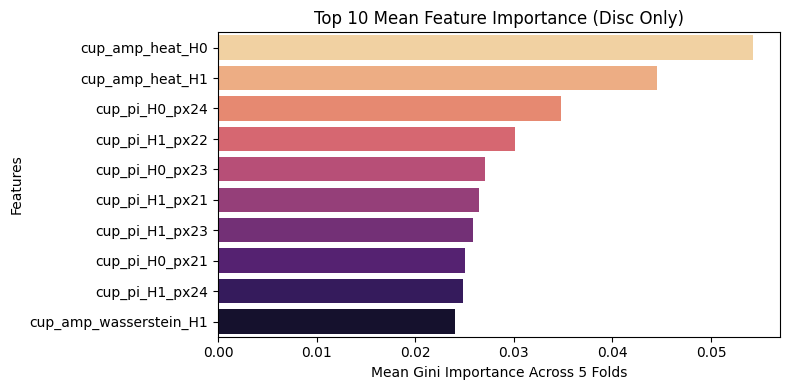

  Aggregated confusion matrix across 5 folds:
[[ 87 112]
 [ 19 529]]
--------------------------------------------------------------------------------

Running feature set: Vessel Only
Number of features: 82
Usable images: 747
Usable patients: 288
  Fold 1 | Train patients: 230 | Val patients:  58 | Train images: 595 | Val images: 152 | AUROC: 0.7310 | Sens: 0.8829 | Spec: 0.4390
  Fold 2 | Train patients: 230 | Val patients:  58 | Train images: 611 | Val images: 136 | AUROC: 0.6531 | Sens: 0.9600 | Spec: 0.2222
  Fold 3 | Train patients: 230 | Val patients:  58 | Train images: 604 | Val images: 143 | AUROC: 0.7693 | Sens: 0.9811 | Spec: 0.2703
  Fold 4 | Train patients: 231 | Val patients:  57 | Train images: 571 | Val images: 176 | AUROC: 0.6746 | Sens: 0.8692 | Spec: 0.3913
  Fold 5 | Train patients: 231 | Val patients:  57 | Train images: 607 | Val images: 140 | AUROC: 0.7768 | Sens: 0.9703 | Spec: 0.3333
  Top 5 mean feature importances across folds:
                 Feature_Name  

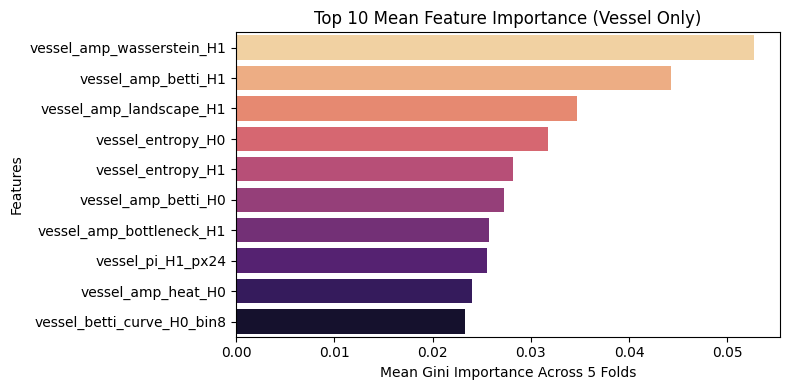

  Aggregated confusion matrix across 5 folds:
[[ 67 132]
 [ 39 509]]
--------------------------------------------------------------------------------

Running feature set: Texture Only
Number of features: 82
Usable images: 747
Usable patients: 288
  Fold 1 | Train patients: 230 | Val patients:  58 | Train images: 595 | Val images: 152 | AUROC: 0.8453 | Sens: 0.9189 | Spec: 0.6341
  Fold 2 | Train patients: 230 | Val patients:  58 | Train images: 611 | Val images: 136 | AUROC: 0.7728 | Sens: 0.9600 | Spec: 0.4722
  Fold 3 | Train patients: 230 | Val patients:  58 | Train images: 604 | Val images: 143 | AUROC: 0.8292 | Sens: 0.9717 | Spec: 0.5135
  Fold 4 | Train patients: 231 | Val patients:  57 | Train images: 571 | Val images: 176 | AUROC: 0.8535 | Sens: 0.9308 | Spec: 0.6087
  Fold 5 | Train patients: 231 | Val patients:  57 | Train images: 607 | Val images: 140 | AUROC: 0.9096 | Sens: 1.0000 | Spec: 0.3846
  Top 5 mean feature importances across folds:
                  Feature_Name

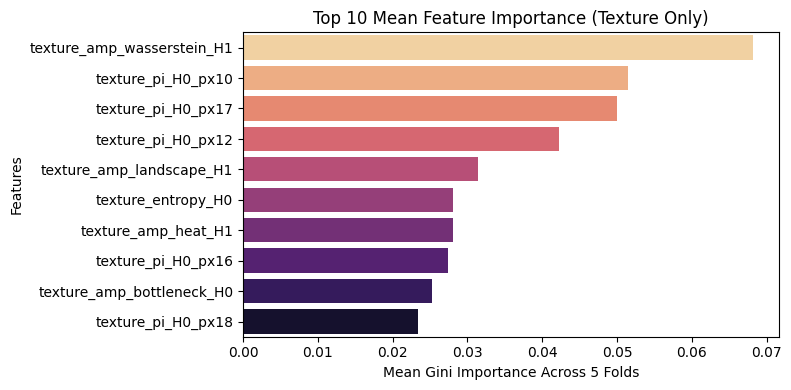

  Aggregated confusion matrix across 5 folds:
[[105  94]
 [ 25 523]]
--------------------------------------------------------------------------------

Running feature set: Disc & Vessel
Number of features: 164
Usable images: 747
Usable patients: 288
  Fold 1 | Train patients: 230 | Val patients:  58 | Train images: 595 | Val images: 152 | AUROC: 0.8086 | Sens: 0.9550 | Spec: 0.5366
  Fold 2 | Train patients: 230 | Val patients:  58 | Train images: 611 | Val images: 136 | AUROC: 0.7928 | Sens: 1.0000 | Spec: 0.3611
  Fold 3 | Train patients: 230 | Val patients:  58 | Train images: 604 | Val images: 143 | AUROC: 0.8809 | Sens: 0.9811 | Spec: 0.3784
  Fold 4 | Train patients: 231 | Val patients:  57 | Train images: 571 | Val images: 176 | AUROC: 0.7172 | Sens: 0.9385 | Spec: 0.4348
  Fold 5 | Train patients: 231 | Val patients:  57 | Train images: 607 | Val images: 140 | AUROC: 0.7639 | Sens: 0.9901 | Spec: 0.4615
  Top 5 mean feature importances across folds:
                 Feature_Nam

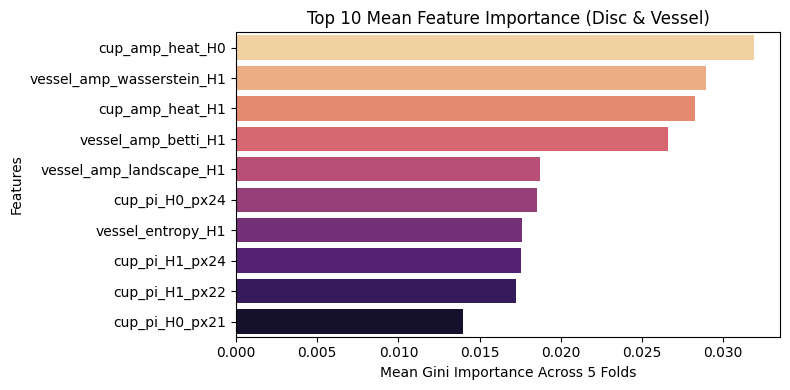

  Aggregated confusion matrix across 5 folds:
[[ 87 112]
 [ 16 532]]
--------------------------------------------------------------------------------

Running feature set: Disc & Texture
Number of features: 164
Usable images: 747
Usable patients: 288
  Fold 1 | Train patients: 230 | Val patients:  58 | Train images: 595 | Val images: 152 | AUROC: 0.8565 | Sens: 0.9189 | Spec: 0.6341
  Fold 2 | Train patients: 230 | Val patients:  58 | Train images: 611 | Val images: 136 | AUROC: 0.8214 | Sens: 0.9600 | Spec: 0.4722
  Fold 3 | Train patients: 230 | Val patients:  58 | Train images: 604 | Val images: 143 | AUROC: 0.8557 | Sens: 0.9717 | Spec: 0.5405
  Fold 4 | Train patients: 231 | Val patients:  57 | Train images: 571 | Val images: 176 | AUROC: 0.8562 | Sens: 0.9308 | Spec: 0.5435
  Fold 5 | Train patients: 231 | Val patients:  57 | Train images: 607 | Val images: 140 | AUROC: 0.9012 | Sens: 0.9901 | Spec: 0.4872
  Top 5 mean feature importances across folds:
                   Feature_

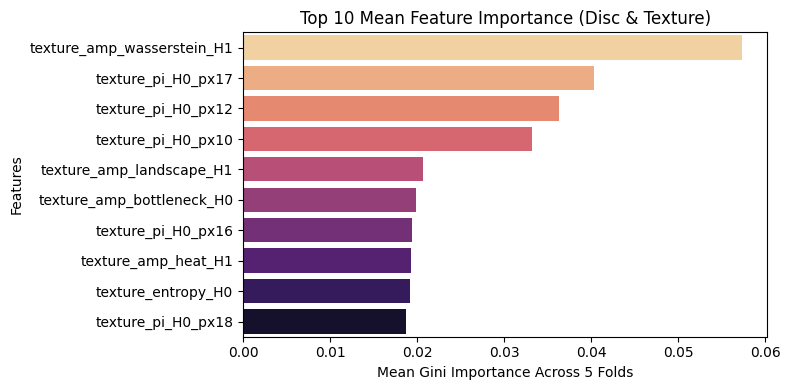

  Aggregated confusion matrix across 5 folds:
[[107  92]
 [ 26 522]]
--------------------------------------------------------------------------------

Running feature set: Vessel & Texture
Number of features: 164
Usable images: 747
Usable patients: 288
  Fold 1 | Train patients: 230 | Val patients:  58 | Train images: 595 | Val images: 152 | AUROC: 0.8332 | Sens: 0.9369 | Spec: 0.6585
  Fold 2 | Train patients: 230 | Val patients:  58 | Train images: 611 | Val images: 136 | AUROC: 0.7814 | Sens: 0.9700 | Spec: 0.5000
  Fold 3 | Train patients: 230 | Val patients:  58 | Train images: 604 | Val images: 143 | AUROC: 0.8197 | Sens: 0.9717 | Spec: 0.5405
  Fold 4 | Train patients: 231 | Val patients:  57 | Train images: 571 | Val images: 176 | AUROC: 0.8478 | Sens: 0.9462 | Spec: 0.5652
  Fold 5 | Train patients: 231 | Val patients:  57 | Train images: 607 | Val images: 140 | AUROC: 0.9104 | Sens: 1.0000 | Spec: 0.4872
  Top 5 mean feature importances across folds:
                   Featur

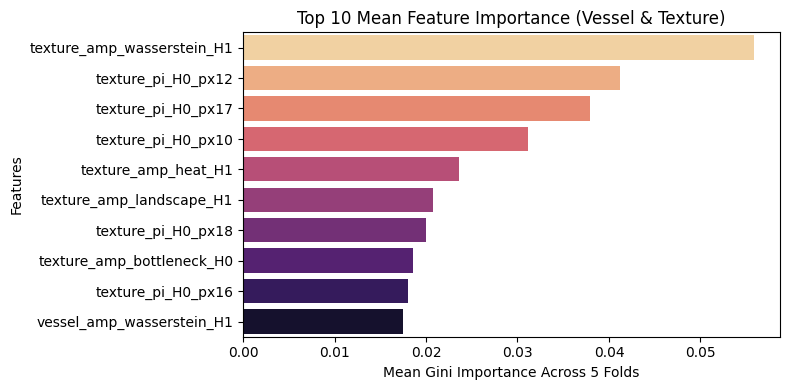

  Aggregated confusion matrix across 5 folds:
[[110  89]
 [ 20 528]]
--------------------------------------------------------------------------------

Running feature set: All three
Number of features: 246
Usable images: 747
Usable patients: 288
  Fold 1 | Train patients: 230 | Val patients:  58 | Train images: 595 | Val images: 152 | AUROC: 0.8482 | Sens: 0.9369 | Spec: 0.6341
  Fold 2 | Train patients: 230 | Val patients:  58 | Train images: 611 | Val images: 136 | AUROC: 0.8072 | Sens: 0.9700 | Spec: 0.4722
  Fold 3 | Train patients: 230 | Val patients:  58 | Train images: 604 | Val images: 143 | AUROC: 0.8483 | Sens: 0.9717 | Spec: 0.4865
  Fold 4 | Train patients: 231 | Val patients:  57 | Train images: 571 | Val images: 176 | AUROC: 0.8457 | Sens: 0.9462 | Spec: 0.5217
  Fold 5 | Train patients: 231 | Val patients:  57 | Train images: 607 | Val images: 140 | AUROC: 0.9023 | Sens: 0.9802 | Spec: 0.5385
  Top 5 mean feature importances across folds:
                   Feature_Name 

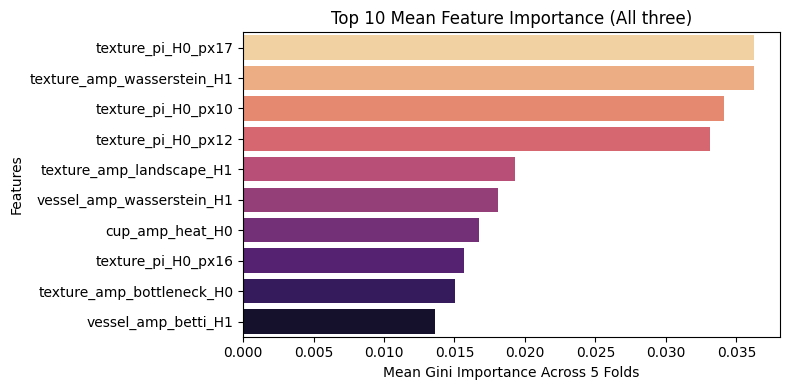

  Aggregated confusion matrix across 5 folds:
[[106  93]
 [ 22 526]]
--------------------------------------------------------------------------------

Final patient-level Stratified 5-Fold CV results
            Feature          AUROC Sensitivity (R+) Specificity (R-)  \
0         Disc Only  0.813 ± 0.047    0.966 ± 0.021    0.436 ± 0.079   
1       Vessel Only  0.721 ± 0.050    0.933 ± 0.047    0.331 ± 0.079   
2      Texture Only  0.842 ± 0.044    0.956 ± 0.029    0.523 ± 0.091   
3     Disc & Vessel  0.793 ± 0.054    0.973 ± 0.023    0.434 ± 0.063   
4    Disc & Texture  0.858 ± 0.025    0.954 ± 0.026    0.536 ± 0.057   
5  Vessel & Texture  0.839 ± 0.042    0.965 ± 0.022    0.550 ± 0.061   
6         All three  0.850 ± 0.030    0.961 ± 0.017    0.531 ± 0.057   

   Num_features  
0            82  
1            82  
2            82  
3           164  
4           164  
5           164  
6           246  
Saved files:
1. tda_7feature_combinations_5fold_results.csv
2. tda_7feature_com

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix


# =========================================================
# 1. Load master feature table
# =========================================================
DATA_PATH = "tda_features_with_quality_master.csv"
df = pd.read_csv(DATA_PATH)

print("=" * 80)
print("Loaded dataset")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print("=" * 80)


# =========================================================
# 2. Basic checks and cleaning
# =========================================================
required_cols = ["Image Name", "patient_id", "label"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Clean key columns
df["Image Name"] = df["Image Name"].astype(str).str.strip()
df["patient_id"] = df["patient_id"].astype(str).str.strip()
df["label_encoded"] = df["label"].astype(str).str.strip().astype(int)

# Drop rows with missing critical fields
df = df.dropna(subset=["Image Name", "patient_id", "label_encoded"]).copy()

print("After cleaning:")
print(f"Total rows: {len(df)}")
print(f"Unique patients: {df['patient_id'].nunique()}")
print("Label distribution:")
print(df["label_encoded"].value_counts())
print("=" * 80)


# =========================================================
# 3. Patient-level leakage check
# =========================================================
patient_df = df[["patient_id", "label_encoded"]].drop_duplicates().reset_index(drop=True)

patient_label_check = patient_df.groupby("patient_id")["label_encoded"].nunique()
bad_patients = patient_label_check[patient_label_check > 1]

if len(bad_patients) > 0:
    raise ValueError(
        "Some patient_id values have more than one label. "
        f"Please check:\n{bad_patients}"
    )

print("Patient-level table created successfully.")
print(f"Number of unique patients: {len(patient_df)}")
print("Patient-level label distribution:")
print(patient_df["label_encoded"].value_counts())
print("=" * 80)


# =========================================================
# 4. Feature combinations
#    Your table uses 'Disc', but actual prefix is 'cup_'
# =========================================================
INCLUDE_QUALITY_SCORE = False
QUALITY_COL = "Quality Score"

all_columns = df.columns.tolist()

feature_sets = {
    "Disc Only": lambda cols: [c for c in cols if c.startswith("cup_")],
    "Vessel Only": lambda cols: [c for c in cols if c.startswith("vessel_")],
    "Texture Only": lambda cols: [c for c in cols if c.startswith("texture_")],
    "Disc & Vessel": lambda cols: [c for c in cols if c.startswith("cup_") or c.startswith("vessel_")],
    "Disc & Texture": lambda cols: [c for c in cols if c.startswith("cup_") or c.startswith("texture_")],
    "Vessel & Texture": lambda cols: [c for c in cols if c.startswith("vessel_") or c.startswith("texture_")],
    "All three": lambda cols: [c for c in cols if c.startswith(("cup_", "vessel_", "texture_"))],
}


# =========================================================
# 5. Cross-validation setting
# =========================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
all_importance_tables = []
all_oof_predictions = []

print("Starting patient-level Stratified 5-Fold CV...")
print("=" * 80)


# =========================================================
# 6. Run all feature combinations
# =========================================================
for feature_name, selector_fn in feature_sets.items():
    feature_cols = selector_fn(all_columns)

    # Optionally add quality score
    if INCLUDE_QUALITY_SCORE and QUALITY_COL in df.columns:
        if QUALITY_COL not in feature_cols:
            feature_cols.append(QUALITY_COL)

    if len(feature_cols) == 0:
        print(f"Skipping {feature_name}: no matching features found.")
        continue

    # Keep only needed columns for this experiment
    current_df = df[["Image Name", "patient_id", "label_encoded"] + feature_cols].copy()
    current_df = current_df.dropna(subset=feature_cols).reset_index(drop=True)

    # Rebuild patient table for this feature set
    current_patient_df = current_df[["patient_id", "label_encoded"]].drop_duplicates().reset_index(drop=True)

    # Check label consistency again
    current_patient_label_check = current_df.groupby("patient_id")["label_encoded"].nunique()
    bad_patients_current = current_patient_label_check[current_patient_label_check > 1]
    if len(bad_patients_current) > 0:
        raise ValueError(
            f"[{feature_name}] Some patient_id values have more than one label:\n"
            f"{bad_patients_current}"
        )

    print(f"\nRunning feature set: {feature_name}")
    print(f"Number of features: {len(feature_cols)}")
    print(f"Usable images: {len(current_df)}")
    print(f"Usable patients: {current_patient_df['patient_id'].nunique()}")

    # Fold-level metric storage
    auroc_list = []
    sensitivity_list = []
    specificity_list = []
    fold_conf_matrices = []
    fold_importances = []

    # Out-of-fold prediction storage
    oof_records = []

    # =====================================================
    # 6A. 5-fold loop
    # =====================================================
    for fold, (train_idx, val_idx) in enumerate(
        skf.split(current_patient_df["patient_id"], current_patient_df["label_encoded"]),
        start=1
    ):
        train_patients = current_patient_df.iloc[train_idx]["patient_id"]
        val_patients = current_patient_df.iloc[val_idx]["patient_id"]

        train_mask = current_df["patient_id"].isin(train_patients)
        val_mask = current_df["patient_id"].isin(val_patients)

        train_df = current_df.loc[train_mask].copy()
        val_df = current_df.loc[val_mask].copy()

        # Extra leakage check
        overlap_patients = set(train_df["patient_id"]).intersection(set(val_df["patient_id"]))
        if len(overlap_patients) > 0:
            raise ValueError(
                f"[{feature_name}] Leakage detected in fold {fold}. "
                f"Overlapping patients: {overlap_patients}"
            )

        X_train = train_df[feature_cols]
        y_train = train_df["label_encoded"]

        X_val = val_df[feature_cols]
        y_val = val_df["label_encoded"]

        # Random Forest model
        model = RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = model.predict(X_val)

        # Metrics
        auroc = roc_auc_score(y_val, y_prob)

        cm = confusion_matrix(y_val, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        auroc_list.append(auroc)
        sensitivity_list.append(sensitivity)
        specificity_list.append(specificity)
        fold_conf_matrices.append(cm)

        # Store feature importance for this fold
        fold_importances.append(model.feature_importances_)

        # Store OOF predictions
        fold_oof = pd.DataFrame({
            "Feature_Set": feature_name,
            "Fold": fold,
            "Image Name": val_df["Image Name"].values,
            "patient_id": val_df["patient_id"].values,
            "y_true": y_val.values,
            "y_prob": y_prob,
            "y_pred": y_pred
        })
        oof_records.append(fold_oof)

        print(
            f"  Fold {fold} | "
            f"Train patients: {len(train_patients):3d} | "
            f"Val patients: {len(val_patients):3d} | "
            f"Train images: {len(train_df):3d} | "
            f"Val images: {len(val_df):3d} | "
            f"AUROC: {auroc:.4f} | "
            f"Sens: {sensitivity:.4f} | "
            f"Spec: {specificity:.4f}"
        )

    # =====================================================
    # 6B. Aggregate fold metrics
    # =====================================================
    result_row = {
        "Feature": feature_name,
        "AUROC_mean": np.mean(auroc_list),
        "AUROC_std": np.std(auroc_list),
        "Sensitivity_mean": np.mean(sensitivity_list),
        "Sensitivity_std": np.std(sensitivity_list),
        "Specificity_mean": np.mean(specificity_list),
        "Specificity_std": np.std(specificity_list),
        "Num_features": len(feature_cols),
        "Num_images_used": len(current_df),
        "Num_patients_used": current_patient_df["patient_id"].nunique(),
    }
    results.append(result_row)

    # =====================================================
    # 6C. Aggregate feature importance across folds
    # =====================================================
    mean_importance = np.mean(fold_importances, axis=0)
    std_importance = np.std(fold_importances, axis=0)

    importance_df = pd.DataFrame({
        "Feature_Set": feature_name,
        "Feature_Name": feature_cols,
        "Importance_mean": mean_importance,
        "Importance_std": std_importance
    }).sort_values("Importance_mean", ascending=False)

    all_importance_tables.append(importance_df)

    # Save OOF predictions for this feature set
    oof_df = pd.concat(oof_records, axis=0, ignore_index=True)
    all_oof_predictions.append(oof_df)

    # Print top 5 important features
    print("  Top 5 mean feature importances across folds:")
    print(importance_df.head(5)[["Feature_Name", "Importance_mean", "Importance_std"]])

    # Optional quick plot for top 10
    top_k = 10
    top_features = importance_df.head(top_k)

    plt.figure(figsize=(8, 4))
    sns.barplot(
        x="Importance_mean",
        y="Feature_Name",
        data=top_features,
        hue="Feature_Name",
        palette="magma_r",
        legend=False
    )
    plt.title(f"Top {top_k} Mean Feature Importance ({feature_name})")
    plt.xlabel("Mean Gini Importance Across 5 Folds")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

    cm_total = np.sum(fold_conf_matrices, axis=0)
    print("  Aggregated confusion matrix across 5 folds:")
    print(cm_total)
    print("-" * 80)


# =========================================================
# 7. Final summary table
# =========================================================
results_df = pd.DataFrame(results)

results_df["AUROC"] = results_df.apply(
    lambda r: f"{r['AUROC_mean']:.3f} ± {r['AUROC_std']:.3f}", axis=1
)
results_df["Sensitivity (R+)"] = results_df.apply(
    lambda r: f"{r['Sensitivity_mean']:.3f} ± {r['Sensitivity_std']:.3f}", axis=1
)
results_df["Specificity (R-)"] = results_df.apply(
    lambda r: f"{r['Specificity_mean']:.3f} ± {r['Specificity_std']:.3f}", axis=1
)

final_display = results_df[
    ["Feature", "AUROC", "Sensitivity (R+)", "Specificity (R-)", "Num_features"]
].copy()

print("\n" + "=" * 80)
print("Final patient-level Stratified 5-Fold CV results")
print(final_display)
print("=" * 80)


# =========================================================
# 8. Save outputs
# =========================================================
# Main result tables
final_display.to_csv("tda_7feature_combinations_5fold_results.csv", index=False)
results_df.to_csv("tda_7feature_combinations_5fold_results_full.csv", index=False)

# Feature importance tables
importance_all_df = pd.concat(all_importance_tables, axis=0, ignore_index=True)
importance_all_df.to_csv("tda_feature_importance_5fold_mean_std.csv", index=False)

# OOF predictions
oof_all_df = pd.concat(all_oof_predictions, axis=0, ignore_index=True)
oof_all_df.to_csv("tda_oof_predictions_5fold.csv", index=False)

print("Saved files:")
print("1. tda_7feature_combinations_5fold_results.csv")
print("2. tda_7feature_combinations_5fold_results_full.csv")
print("3. tda_feature_importance_5fold_mean_std.csv")
print("4. tda_oof_predictions_5fold.csv")

SHAP for local interpretability

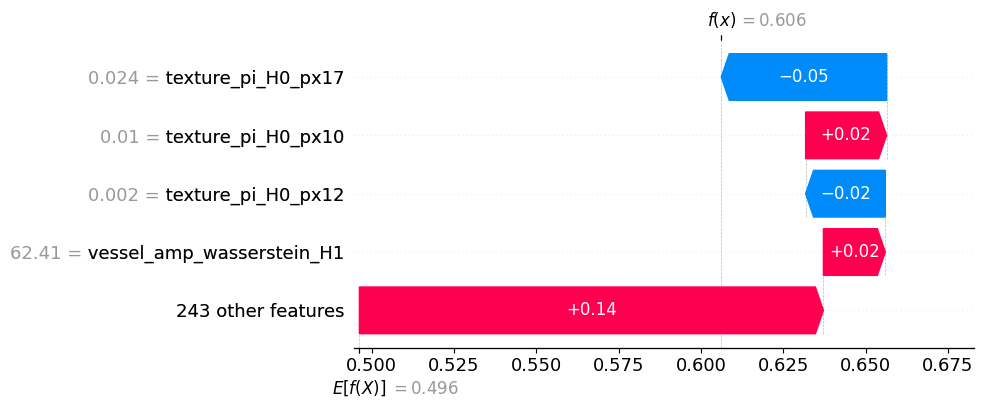

In [5]:
import pandas as pd
import shap
import numpy as np

# ===== Load data again (avoid variable missing issues) =====
df_train = pd.read_csv("tda_train_final.csv")
df_test = pd.read_csv("tda_test_final.csv")

cols_to_drop = ['Image Name', 'label_encoded']

X_train = df_train.drop(columns=cols_to_drop)
X_test = df_test.drop(columns=cols_to_drop)

y_train = df_train['label_encoded']
y_test = df_test['label_encoded']

# ===== Train model =====
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

# ===== Pick one case (better than iloc[5]) =====
y_prob = rf.predict_proba(X_test)[:, 1]
idx = np.argmin(np.abs(y_prob - 0.61))


patient_data = X_test.iloc[[idx]]

# ===== SHAP =====
explainer = shap.TreeExplainer(rf)
shap_values_obj = explainer(patient_data)[:, :, 1]

bv = shap_values_obj.base_values[0]

final_explanation = shap.Explanation(
    values=shap_values_obj.values[0],
    base_values=bv,
    data=patient_data.values[0],
    feature_names=patient_data.columns.tolist()
)

# ===== Plot =====
shap.plots.waterfall(final_explanation, max_display=5)

Bin features according to landscape for SHAP

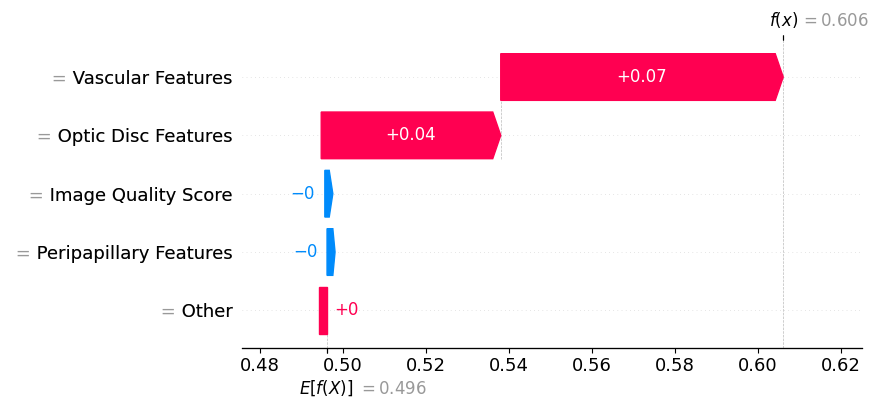

In [8]:
import shap
import numpy as np

# 1. Build category map from the actual features used in the trained model
prefix_map = {
    'cup_': 'Optic Disc Features',
    'vessel_': 'Vascular Features',
    'texture_': 'Peripapillary Features',
    'Quality': 'Image Quality Score'
}

category_map = {label: [] for label in prefix_map.values()}
category_map['Other'] = []

for col in X_train.columns:
    found = False
    for prefix, label in prefix_map.items():
        if col.startswith(prefix):
            category_map[label].append(col)
            found = True
            break
    if not found:
        category_map['Other'].append(col)

# 2. Use the SAME sample as your previous SHAP block
# patient_data should already be defined in your previous block
patient_data = patient_data[X_train.columns]

# 3. SHAP values from the SAME trained model
explainer = shap.TreeExplainer(rf)
shap_values_obj = explainer(patient_data, check_additivity=False)

# For binary classification, use the positive class
values_1sample = shap_values_obj.values[0, :, 1]
base_value = shap_values_obj.base_values[0, 1]

# 4. Aggregate SHAP values by category
group_names = list(category_map.keys())
aggregated_values = []

for cat in group_names:
    indices = [patient_data.columns.get_loc(f) for f in category_map[cat] if f in patient_data.columns]

    if len(indices) > 0:
        cat_sum = values_1sample[indices].sum()
    else:
        cat_sum = 0.0

    aggregated_values.append(cat_sum)

aggregated_values = np.array(aggregated_values)

# 5. Dummy display values
data_1d = np.full(len(aggregated_values), "")

# 6. Build grouped explanation
final_explanation = shap.Explanation(
    values=aggregated_values,
    base_values=base_value,
    data=data_1d,
    feature_names=group_names
)

# 7. Plot
shap.plots.waterfall(final_explanation)

Export RF model for streamlit app

In [9]:
import joblib
joblib.dump(rf, 'tda_rf_model.joblib')

['tda_rf_model.joblib']